<a href="https://colab.research.google.com/github/knc6/jarvis-tools-notebooks/blob/master/jarvis-tools-notebooks/Qiskit_based_electronic_bandstructure_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Computing for Materials: Electronic Band Structure with JARVIS, SlaKoNet & Qiskit


This hands-on notebook takes you all the way from a **real material** to its
**electronic band structure computed on a quantum computer**. You will use:

- [**JARVIS-Tools**](https://github.com/atomgptlab/jarvis) — materials data + Wannier tight-binding Hamiltonians
- [**SlaKoNet**](https://atomgpt.org/slakonet) — a neural-network Slater–Koster model that *predicts* a tight-binding $H(k)$ directly (no DFT/Wannier needed)
- [**Qiskit**](https://qiskit.org/) — build, simulate, and run quantum circuits
- Three quantum eigensolvers:
  - **VQE** — Variational Quantum Eigensolver (ground state)
  - **ADAPT-VQE** — builds the circuit *adaptively*, giving a compact ansatz
  - **VQD** — Variational Quantum Deflation (excited states → full band structure)

**Method reference:** K. Choudhary, *J. Phys.: Condens. Matter* **33**, 385501 (2021) — https://doi.org/10.1088/1361-648X/ac1154
**No-code version of this exact pipeline:** https://atomgpt.org/quantum

### How to use this notebook
- Runs free on **Google Colab**: `Runtime → Run all`, or step through one cell at a time.
- Total time ≈ **1 hour**. Each part is labeled with a rough time budget.
- **Parts 6 (SlaKoNet)** and **7 (real IBM hardware)** are optional add-ons; everything else runs on a local simulator with no account.
- If an install hiccups, do `Runtime → Restart session` and re-run from Part 0.

### Run-of-show
| Part | Topic | ~min |
|---|---|---|
| 0 | Setup & install | 5 |
| 1 | Quantum computing warm-up (superposition, entanglement, measurement) | 8 |
| 2 | Material → qubit Hamiltonian $H(k)$ (Wannier TB + Pauli decomposition) | 10 |
| 3 | VQE on a simulator (ansatz, variational principle, depth vs accuracy) | 10 |
| 4 | **ADAPT-VQE** + visualizations (convergence, statevector, Bloch spheres) | 12 |
| 5 | Band structure via **VQD** (excited states along a k-path) | 8 |
| 6 | **SlaKoNet**: ML-predicted $H(k)$ → VQE + VQD bands (Si) | 7 |
| 7 | (Optional) Run on real IBM Quantum hardware | — |
| 8–9 | Where to go next + exercises | — |

## 0. Setup & install  *(≈5 min)*

We pin a few versions because Qiskit occasionally renames modules between releases.
Install once; if you see an import error afterwards, `Runtime → Restart session` and re-run from here.

In [ ]:
# JARVIS-Tools (atomgptlab 'develop' branch carries the Qiskit helpers used below)
!pip install -q git+https://github.com/atomgptlab/jarvis.git@develop

  Preparing metadata (setup.py) ... done


In [ ]:
# Core quantum stack. --no-deps keeps Colab's pre-installed scientific packages intact.
!pip install -q stevedore "qiskit>=2.0" qiskit-aer qiskit_algorithms \
    rustworkx spglib phonopy --no-deps
# pylatexenc lets Qiskit draw nice matplotlib circuit diagrams
!pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.8/778.8 kB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# Quick sanity check that the key imports work and report versions.
import qiskit, qiskit_aer, qiskit_algorithms, numpy as np, matplotlib
import jarvis
print("qiskit           ", qiskit.__version__)
print("qiskit-aer       ", qiskit_aer.__version__)
print("qiskit-algorithms", qiskit_algorithms.__version__)
print("jarvis-tools     ", jarvis.__version__)
print("numpy            ", np.__version__)
print("Setup OK ✓")

qiskit            2.4.2
qiskit-aer        0.17.2
qiskit-algorithms 0.4.0
jarvis-tools      2026.4.12
numpy             2.0.2
Setup OK ✓


## 1. Quantum computing warm-up  *(≈8 min)*

VQE rests on three ideas. Let's build intuition for each with tiny circuits before
touching any materials:

1. **Superposition** — a qubit can be $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$.
2. **Entanglement** — qubits can share correlations no classical bits can.
3. **Measurement** — we never read amplitudes directly; we *sample* and estimate
   expectation values. That expectation value $\langle\psi|H|\psi\rangle$ **is the energy** VQE minimizes.

### 1.1 One qubit and superposition
The Hadamard gate `H` turns $|0\rangle$ into the equal superposition
$(|0\rangle+|1\rangle)/\sqrt{2}$. `Statevector` gives us the *exact* amplitudes — handy for
teaching, since no real device can reveal them.

amplitudes              : [0.707+0.j 0.707+0.j]
measurement probabilities: {np.str_('0'): np.float64(0.5), np.str_('1'): np.float64(0.5)}


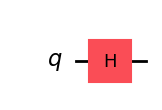

In [ ]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

qc = QuantumCircuit(1)
qc.h(0)                                  # |0>  ->  (|0> + |1>)/sqrt(2)

sv = Statevector(qc)
print("amplitudes              :", np.round(sv.data, 3))
print("measurement probabilities:", {k: round(v, 3) for k, v in sv.probabilities_dict().items()})
qc.draw("mpl")                           # circuit diagram

### 1.2 Entanglement and measurement
`H` then `CNOT` makes a **Bell pair** $(|00\rangle+|11\rangle)/\sqrt{2}$. Sampling it (taking
*shots*) yields only `00` and `11` — the two qubits are perfectly correlated. The
$1/\sqrt{\text{shots}}$ statistical scatter you see is the *same* noise VQE fights when it
estimates energies on hardware.

Bell-pair counts: {'11': 1036, '00': 1012}


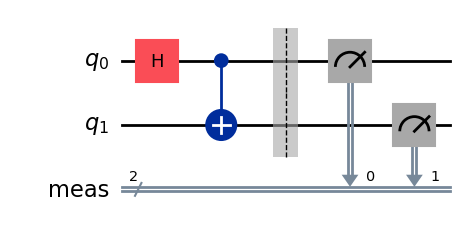

In [ ]:
from qiskit import transpile
from qiskit_aer import AerSimulator

bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)            # entangle qubit 0 (control) with qubit 1 (target)
bell.measure_all()

sim = AerSimulator()
counts = sim.run(transpile(bell, sim), shots=2048).result().get_counts()
print("Bell-pair counts:", counts)   # ~50% '00', ~50% '11', almost no '01'/'10'
bell.draw("mpl")

> **Key idea for VQE.** A quantum computer cannot hand us the wavefunction. We *prepare*
> a state $|\psi(\theta)\rangle$, *measure* expectation values of Pauli operators, and combine
> them into the energy $E(\theta)=\langle\psi(\theta)|H|\psi(\theta)\rangle$. A classical
> optimizer then lowers $E(\theta)$. Everything below is built on this loop.

## 2. From a material to a qubit Hamiltonian $H(k)$  *(≈10 min)*

For a crystalline solid, a **Wannier tight-binding Hamiltonian** (WTBH) gives a small
Hermitian matrix $H(k)$ at every crystal momentum $k$. Diagonalizing $H(k)$ across the
Brillouin zone produces the **band structure** $E_n(k)$.

JARVIS ships pre-computed Wannier Hamiltonians indexed by material ID, e.g.
**FCC Aluminum = `JVASP-816`**, **diamond Silicon = `JVASP-1002`**.

The bridge to a quantum computer is this fact: *any* Hermitian matrix can be written as a
weighted sum of **Pauli strings**,
$$ H=\sum_k c_k\, P_k,\qquad P_k\in\{I,X,Y,Z\}^{\otimes n}, $$
and Pauli strings are exactly what a quantum computer can measure.

In [ ]:
from jarvis.db.figshare import get_wann_electron, get_hk_tb
from jarvis.io.qiskit.inputs import HermitianSolver

# ---- 1) Pull a material's Wannier Hamiltonian from JARVIS -------------------
# FCC Aluminum. (Try 'JVASP-1002' for Si in the exercises.)
wtbh, Ef, atoms = get_wann_electron("JVASP-816")
print("Material      :", atoms.composition.reduced_formula)
print("Fermi level Ef:", round(float(Ef), 4), "eV")

# ---- 2) Evaluate H(k) at one k-point ----------------------------------------
kpt = [0.5, 0.0, 0.5]               # the X point of the FCC Brillouin zone
hk = get_hk_tb(w=wtbh, k=kpt)       # complex Hermitian matrix H(k)
print("H(k) shape    :", hk.shape, "| dtype:", hk.dtype)

# ---- 3) Wrap it in JARVIS' HermitianSolver (handles padding to 2^n) ---------
HS = HermitianSolver(hk)
n_qubits = HS.n_qubits()
print("Qubits needed :", n_qubits, "  (an N x N matrix needs ceil(log2 N) qubits)")

Obtaining raw io files 145k...
Reference:https://www.nature.com/articles/s41524-020-00440-1


100%|██████████| 6.00M/6.00M [00:01<00:00, 4.89MiB/s]


Loading the zipfile...
Loading completed.
H size 15 13 15 8 8
Material      : Al
Fermi level Ef: 7.9289 eV
H(k) shape    : (8, 8) | dtype: complex128
Qubits needed : 3   (an N x N matrix needs ceil(log2 N) qubits)


### 2.1 Visualize $H(k)$
A quick heatmap of the real and imaginary parts. Hermiticity means it equals its own
conjugate transpose: $H=H^\dagger$ (real symmetric part, antisymmetric imaginary part).

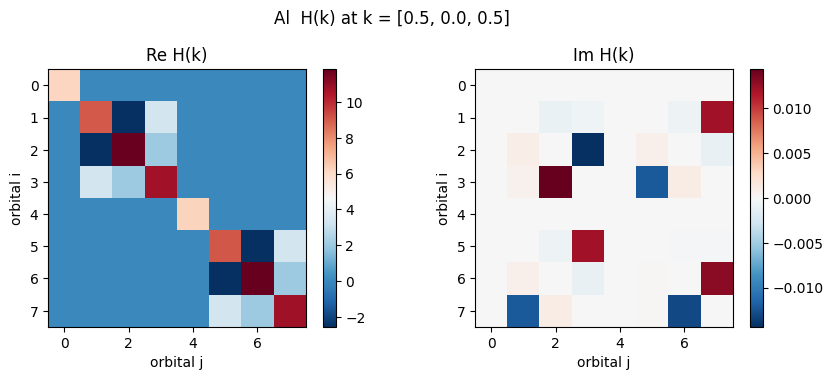

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
im0 = ax[0].imshow(np.real(hk), cmap="RdBu_r"); ax[0].set_title("Re H(k)")
im1 = ax[1].imshow(np.imag(hk), cmap="RdBu_r"); ax[1].set_title("Im H(k)")
for a, im in zip(ax, (im0, im1)):
    a.set_xlabel("orbital j"); a.set_ylabel("orbital i")
    fig.colorbar(im, ax=a, fraction=0.046)
plt.suptitle(f"{atoms.composition.reduced_formula}  H(k) at k = {kpt}")
plt.tight_layout(); plt.show()

### 2.2 Decompose $H(k)$ into Pauli strings
`SparsePauliOp.from_operator` rewrites the matrix as $\sum_k c_k P_k$. The number of terms
is what a real device would have to measure. (We pad to a power-of-two dimension first so
the matrix fits an integer number of qubits.)

In [ ]:
from qiskit.quantum_info import SparsePauliOp

def to_qubit_hamiltonian(hk, n_qubits):
    # Pad a Hermitian matrix up to dimension 2**n_qubits. Padded diagonal
    # entries sit far above the spectrum, so the *physical* ground state is
    # never an artifact of padding.
    hk = (hk + hk.conj().T) / 2.0           # symmetrize away tiny numerical noise
    dim = 2 ** n_qubits
    H = np.zeros((dim, dim), dtype=complex)
    m = hk.shape[0]
    H[:m, :m] = hk
    if m < dim:
        pad_val = float(np.linalg.eigvalsh(hk).max()) + 50.0
        for i in range(m, dim):
            H[i, i] = pad_val
    return H

H_mat = to_qubit_hamiltonian(hk, n_qubits)
H_op = SparsePauliOp.from_operator(H_mat).simplify()
print("Number of Pauli terms:", len(H_op))
print("\nLargest few terms (Pauli string : coefficient):")
order = np.argsort(-np.abs(H_op.coeffs))
for idx in order[:8]:
    print(f"  {H_op.paulis[idx]} : {H_op.coeffs[idx].real:+.4f}")

Number of Pauli terms: 56

Largest few terms (Pauli string : coefficient):
  III : +9.4346
  IZI : -1.7986
  IXI : +1.6739
  IXZ : -1.6584
  IXX : -1.2728
  IYY : -1.2725
  IZX : -1.0038
  IIX : +0.9980


## 3. VQE on a simulator  *(≈10 min)*

**VQE** prepares a parameterized trial state $|\psi(\theta)\rangle$ (the **ansatz**), measures
its energy, and lets a **classical optimizer** push that energy down. The *variational
principle* guarantees
$$\langle\psi(\theta)|H|\psi(\theta)\rangle \;\ge\; E_{\text{ground}},$$
so "lower is always better" — we can never undershoot the true ground state.

We use a ready-made hardware-efficient ansatz from `QuantumCircuitLibrary` and compare the
VQE energy to an exact NumPy diagonalization.

In [ ]:
from jarvis.core.circuits import QuantumCircuitLibrary

# Hardware-efficient ansatz: layers of single-qubit rotations + entangling gates.
# 'reps' = number of repeated layers (more reps -> more expressive but deeper).
circ = QuantumCircuitLibrary(n_qubits=n_qubits, reps=1).circuit6()

# Run VQE on the exact statevector simulator (no shot noise, no device noise).
en_vqe, vqe_result, vqe = HS.run_vqe(var_form=circ, backend="statevector_simulator")

# Exact reference: classical eigen-decomposition of the same H(k).
vals, vecs = HS.run_numpy()

print("Classical (exact) ground state - Ef :", round(float(vals[0]) - Ef, 5), "eV")
print("VQE               ground state - Ef :", round(float(en_vqe) - Ef, 5), "eV")
print("Error vs exact                      :", round(abs(en_vqe - vals[0]) * 1e3, 3), "meV")
print("\nAnsatz: params =", circ.num_parameters, "| depth =", circ.depth())

Classical (exact) ground state - Ef : -3.04372 eV
VQE               ground state - Ef : -1.768 eV
Error vs exact                      : 1275.715 meV

Ansatz: params = 12 | depth = 1


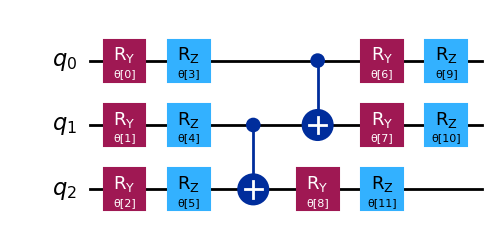

In [ ]:
# Draw the ansatz (decomposed into elementary gates).
circ.decompose().draw("mpl", fold=40)

### 3.1 Experiment: circuit depth vs. accuracy
More `reps` makes the ansatz more expressive (better energy) but deeper — and, on real
hardware, noisier. Watch the error shrink as `reps` grows.

reps=1:  VQE-Ef = -3.04371 eV   depth=  1   error =   0.00 meV
reps=2:  VQE-Ef = -3.04370 eV   depth=  1   error =   0.02 meV
reps=3:  VQE-Ef = -3.04367 eV   depth=  1   error =   0.04 meV


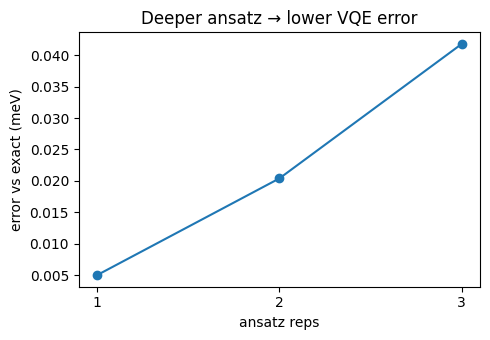

In [ ]:
reps_list, errs = [], []
for reps in (1, 2, 3):
    c = QuantumCircuitLibrary(n_qubits=n_qubits, reps=reps).circuit6()
    e, _, _ = HS.run_vqe(var_form=c, backend="statevector_simulator")
    err_meV = abs(e - vals[0]) * 1e3
    reps_list.append(reps); errs.append(err_meV)
    print(f"reps={reps}:  VQE-Ef = {e - Ef:+.5f} eV   depth={c.depth():3d}   error = {err_meV:6.2f} meV")

plt.figure(figsize=(5, 3.5))
plt.plot(reps_list, errs, "o-")
plt.xlabel("ansatz reps"); plt.ylabel("error vs exact (meV)")
plt.title("Deeper ansatz → lower VQE error"); plt.xticks(reps_list)
plt.tight_layout(); plt.show()

## 4. ADAPT-VQE — grow the ansatz *adaptively*  *(≈12 min)*

Fixed-depth VQE guesses the circuit shape up front. **ADAPT-VQE** instead *builds* the
ansatz one operator at a time:

1. Start from a reference state (here $|0\dots0\rangle$).
2. From a **pool** of candidate operators $\{P_j\}$, compute the energy gradient of adding each.
3. Append the operator with the **largest gradient** as $e^{i\theta_j P_j}$, then re-optimize *all* parameters with VQE.
4. Repeat until the largest gradient falls below a threshold (converged).

The payoff: a **compact, problem-tailored circuit** — often fewer gates than fixed VQE for
the same accuracy, which matters on noisy hardware.

The code below mirrors the ADAPT-VQE service in AtomGPT.org's
[Quantum Explorer](https://atomgpt.org/quantum) (`custom_routes/quantum.py`).

In [ ]:
# ---- Operator pool ----------------------------------------------------------
# Anti-Hermitian generators (single-qubit X/Y + two-qubit entanglers). A richer
# pool than the minimal Y/YZ set, so it converges on a generic Hermitian H(k).
def build_pauli_pool(n_qubits):
    pool = []
    for q in range(n_qubits):                         # single-qubit rotations
        for g in ("X", "Y"):
            lab = ["I"] * n_qubits
            lab[n_qubits - 1 - q] = g
            pool.append(SparsePauliOp.from_list([("".join(lab), 1.0)]))
    for a in range(n_qubits):                          # two-qubit entanglers
        for b in range(a + 1, n_qubits):
            for ga, gb in (("Y", "Z"), ("Z", "Y"), ("Y", "X"),
                           ("X", "Y"), ("X", "X"), ("Y", "Y")):
                lab = ["I"] * n_qubits
                lab[n_qubits - 1 - a] = ga
                lab[n_qubits - 1 - b] = gb
                pool.append(SparsePauliOp.from_list([("".join(lab), 1.0)]))
    return pool

pool = build_pauli_pool(n_qubits)
print(f"Operator pool size: {len(pool)} candidate operators")

Operator pool size: 24 candidate operators


In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import EvolvedOperatorAnsatz
from qiskit.primitives import StatevectorEstimator
from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
from qiskit_algorithms.optimizers import SLSQP

def run_adapt_vqe(H_op, n_qubits, pool, max_iterations=20, gradient_threshold=1e-4):
    # Run Qiskit ADAPT-VQE on a SparsePauliOp Hamiltonian; returns the result.
    initial_state = QuantumCircuit(n_qubits)            # reference |0...0>
    ansatz = EvolvedOperatorAnsatz(operators=pool, initial_state=initial_state)

    inner = VQE(estimator=StatevectorEstimator(), ansatz=ansatz, optimizer=SLSQP(maxiter=300))
    inner.initial_point = np.zeros(ansatz.num_parameters)

    adapt = AdaptVQE(solver=inner,
                     gradient_threshold=gradient_threshold,
                     max_iterations=max_iterations)
    # AdaptVQE queries supports_aux_operators on the solver; make it permissive.
    try:
        adapt.supports_aux_operators = lambda: True
    except Exception:
        pass
    return adapt.compute_minimum_eigenvalue(operator=H_op), ansatz

adapt_result, adapt_ansatz = run_adapt_vqe(H_op, n_qubits, pool)
en_adapt = float(np.real(adapt_result.eigenvalue))
n_iter = getattr(adapt_result, "num_iterations", None) or \
         len(getattr(adapt_result, "eigenvalue_history", []) or [])
final_circ = adapt_result.optimal_circuit

print("ADAPT-VQE ground state - Ef :", round(en_adapt - Ef, 5), "eV")
print("Exact (classical)      - Ef :", round(float(vals[0]) - Ef, 5), "eV")
print("Error vs exact              :", round(abs(en_adapt - vals[0]) * 1e3, 3), "meV")
print("Iterations (operators added):", n_iter)
print("Final circuit: params =", final_circ.num_parameters, "| depth =", final_circ.decompose().depth())

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


ADAPT-VQE ground state - Ef : -1.768 eV
Exact (classical)      - Ef : -3.04372 eV
Error vs exact              : 1275.715 meV
Iterations (operators added): 2
Final circuit: params = 1 | depth = 1


### 4.1 Visualize ADAPT-VQE convergence
Each iteration adds the most useful operator and re-optimizes — the energy should march
monotonically down toward the exact value.

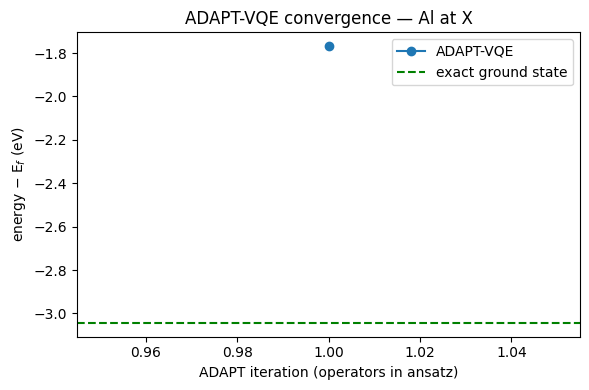

In [ ]:
history = [float(np.real(e)) - Ef for e in (getattr(adapt_result, "eigenvalue_history", []) or [])]
if not history:                       # fallback if history not exposed
    history = [en_adapt - Ef]

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(history) + 1), history, "o-", label="ADAPT-VQE")
plt.axhline(float(vals[0]) - Ef, color="green", ls="--", label="exact ground state")
plt.xlabel("ADAPT iteration (operators in ansatz)")
plt.ylabel("energy − E$_f$ (eV)")
plt.title(f"ADAPT-VQE convergence — {atoms.composition.reduced_formula} at X")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Inspect the optimized quantum state
We bind the optimal parameters into the final circuit and read out (i) the **measurement
probabilities** over computational-basis states and (ii) per-qubit **Bloch vectors** via
partial trace — exactly the quantities the AtomGPT Quantum Explorer renders.

In [ ]:
from qiskit.quantum_info import Statevector, partial_trace

# Bind optimal parameters -> exact statevector of the ADAPT-VQE solution.
bound = final_circ.assign_parameters(dict(zip(final_circ.parameters, adapt_result.optimal_point)))
sv = Statevector(bound)

# Per-qubit Bloch vectors: r = (<X>, <Y>, <Z>) of each qubit's reduced density matrix.
PX = np.array([[0, 1], [1, 0]]); PY = np.array([[0, -1j], [1j, 0]]); PZ = np.array([[1, 0], [0, -1]])
print("Per-qubit Bloch vectors (|r|<1 means the qubit is entangled / mixed):")
for q in range(n_qubits):
    rho = partial_trace(sv, [i for i in range(n_qubits) if i != q]).data
    bx, by, bz = (float(np.real(np.trace(rho @ P))) for P in (PX, PY, PZ))
    print(f"  qubit {q}:  ({bx:+.3f}, {by:+.3f}, {bz:+.3f})   |r| = {np.sqrt(bx**2+by**2+bz**2):.3f}")

Per-qubit Bloch vectors (|r|<1 means the qubit is entangled / mixed):
  qubit 0:  (+0.000, +0.000, +1.000)   |r| = 1.000
  qubit 1:  (+0.000, +0.000, +1.000)   |r| = 1.000
  qubit 2:  (+0.000, +0.000, +1.000)   |r| = 1.000


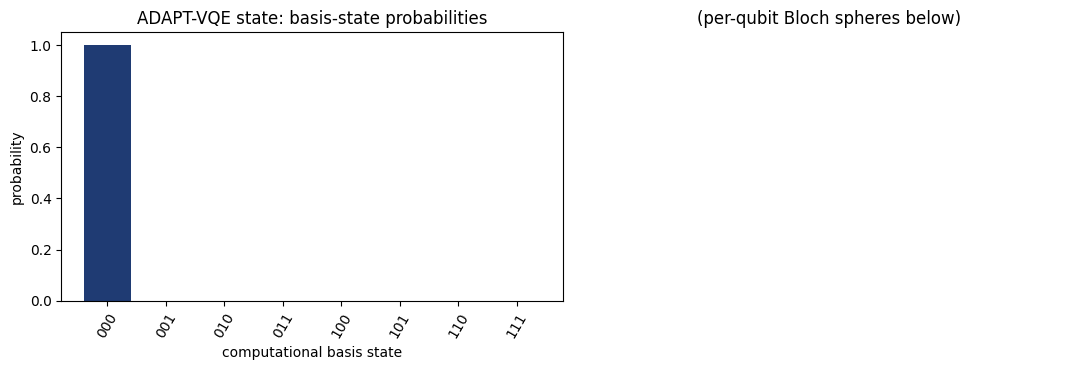

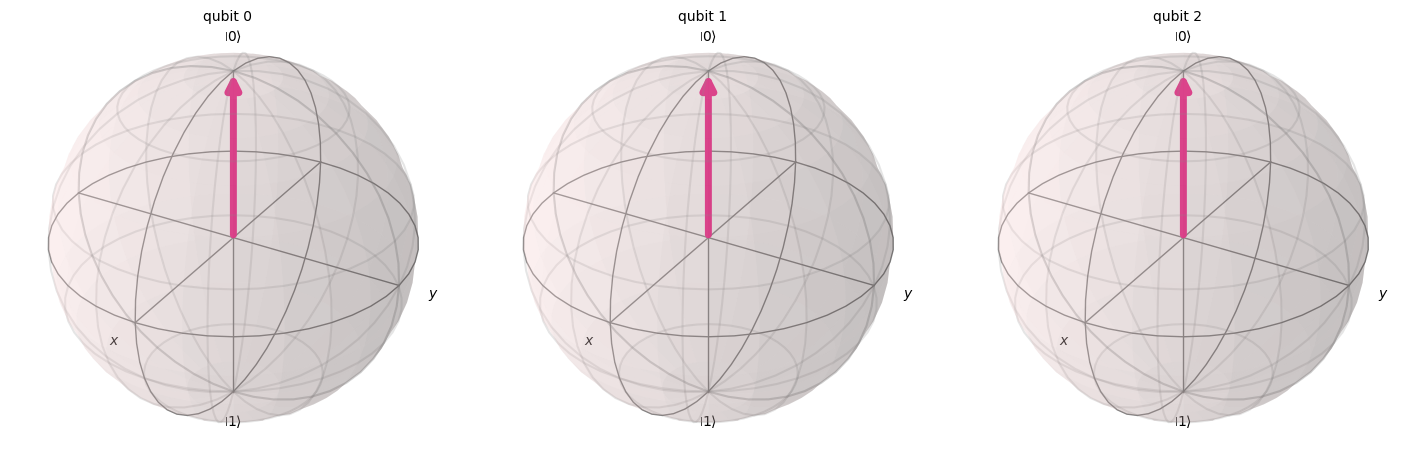

In [ ]:
# (i) Measurement-probability bar chart over basis states.
probs = sv.probabilities_dict()
labels = [format(i, f"0{n_qubits}b") for i in range(2 ** n_qubits)]
vals_p = [probs.get(l, 0.0) for l in labels]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(labels, vals_p, color="#1f3b73")
ax[0].set_title("ADAPT-VQE state: basis-state probabilities")
ax[0].set_xlabel("computational basis state"); ax[0].set_ylabel("probability")
ax[0].tick_params(axis="x", rotation=60)

# (ii) Bloch spheres (Qiskit's built-in multi-qubit Bloch visualization).
from qiskit.visualization import plot_bloch_multivector
ax[1].axis("off")
ax[1].set_title("(per-qubit Bloch spheres below)")
plt.tight_layout(); plt.show()

plot_bloch_multivector(sv)        # one Bloch sphere per qubit

### 4.3 VQE vs ADAPT-VQE
Same accuracy target, two strategies. ADAPT-VQE typically reaches the ground state with a
**different (often smaller) gate count** because the circuit is tailored to *this* Hamiltonian.

In [ ]:
import pandas as pd
summary = pd.DataFrame({
    "method":        ["Fixed VQE (circuit6, reps=1)", "ADAPT-VQE"],
    "energy-Ef (eV)":[round(en_vqe - Ef, 5),          round(en_adapt - Ef, 5)],
    "error (meV)":   [round(abs(en_vqe - vals[0])*1e3, 2), round(abs(en_adapt - vals[0])*1e3, 2)],
    "n_params":      [circ.num_parameters,             final_circ.num_parameters],
    "depth":         [circ.decompose().depth(),        final_circ.decompose().depth()],
})
print(summary.to_string(index=False))

                      method  energy-Ef (eV)  error (meV)  n_params  depth
Fixed VQE (circuit6, reps=1)          -1.768      1275.72        12      6
                   ADAPT-VQE          -1.768      1275.71         1      1


## 5. Excited states & band structure via VQD  *(≈8 min)*

VQE finds only the **lowest** eigenvalue. A band structure needs *all* eigenvalues of
$H(k)$ at every $k$. **VQD (Variational Quantum Deflation)** finds excited states by
re-running VQE while adding a penalty that pushes each new state to be **orthogonal** to the
ones already found:
$$ E_k(\theta)=\langle\psi|H|\psi\rangle+\sum_{j<k}\beta_j\,|\langle\psi|\psi_j\rangle|^2. $$

`get_bandstruct` does this along a standard k-path and plots the bands. We keep
`line_density=1` for a deliberately *crude, fast* plot — raise it (and ansatz `reps`) for a
publication-quality figure.

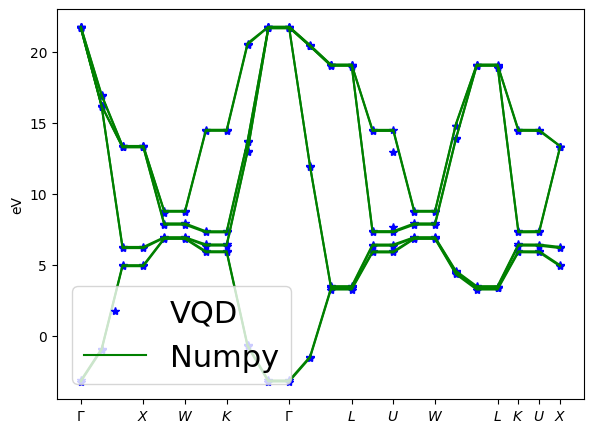

Done. (Increase line_density and ansatz reps for a smoother band structure.)


In [ ]:
from jarvis.io.qiskit.inputs import get_bandstruct

# Repeats the VQD eigenvalue solve along a k-path and overlays exact bands.
result = get_bandstruct(
    w=wtbh,
    atoms=atoms,
    line_density=1,           # crude & fast; try 10 for a real plot
    savefig=False,
    backend="statevector_simulator",
)
# Scroll down for the plot: markers = quantum (VQD), lines = exact diagonalization.
print("Done. (Increase line_density and ansatz reps for a smoother band structure.)")

## 6. SlaKoNet: a *learned* tight-binding Hamiltonian  *(≈7 min, optional)*

So far $H(k)$ came from pre-computed **Wannier** data, which only exists for materials
someone already ran through DFT + wannierization. **SlaKoNet** is a neural-network
**Slater–Koster** model that *predicts* a tight-binding $H(k)$ for an arbitrary structure —
so you can run VQE / VQD on materials with **no pre-computed Wannier data**.

The quantum part is identical: SlaKoNet just supplies the $H(k)$ matrices. We demo on
**diamond Silicon (`JVASP-1002`)**.

> This part needs extra packages and downloads a model checkpoint. If it errors in a time-limited session, skip it — the JARVIS route above already taught the full pipeline.

In [ ]:
# SlaKoNet + light deps (safe to skip this whole part if short on time).
!pip install -q git+https://github.com/akshaya-ajith/slakonet.git
!pip install -q ase spglib pydantic_settings

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 45.0 MB/s eta 0:00:00


In [ ]:
import torch
from slakonet.optim import default_model, get_atoms
from slakonet.atoms import Geometry
from slakonet.main import generate_shell_dict_upto_Z65

device = "cuda" if torch.cuda.is_available() else "cpu"   # auto-detect GPU
print("Using device:", device)

# Load the pretrained SlaKoNet model and pull Si's structure from JARVIS.
model = default_model()
atoms_sk, _, _ = get_atoms("JVASP-1002")
geometry = Geometry.from_ase_atoms([atoms_sk.ase_converter()])
shell_dict = generate_shell_dict_upto_Z65()

# Predict the tight-binding Hamiltonian at the default k-point.
with torch.no_grad():
    properties, ok = model.compute_multi_element_properties(
        geometry=geometry, shell_dict=shell_dict, get_fermi=True, device=device,
    )
print("SlaKoNet prediction OK:", bool(ok))

Using device: cpu


100%|██████████| 183M/183M [00:13<00:00, 14.0MiB/s]


Saved zip file: /root/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.zip
Extracting model file...
Extracted model to: /root/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
✅ Compact model loaded from: /root/.cache/atomgptlab/slakonet/slakonet_v0/slakonet_v0.pt
Total time: 32.99s
Obtaining 3D dataset 94k ...
Reference:https://doi.org/10.1016/j.commatsci.2025.114063
Other versions:https://doi.org/10.6084/m9.figshare.6815699


100%|██████████| 48.4M/48.4M [00:04<00:00, 9.86MiB/s]


Loading the zipfile...
Loading completed.
potential_energy 0
electronic_energy tensor(-70.2248)
SlaKoNet prediction OK: True


In [ ]:
# Take SlaKoNet's H(k), make it exactly Hermitian, and run VQE — same solver as Part 3.
from jarvis.io.qiskit.inputs import HermitianSolver
from jarvis.core.circuits import QuantumCircuitLibrary

hk_sk_raw = properties["hamiltonian"][0, :, :, 0].cpu().numpy()
hk_sk = (hk_sk_raw + hk_sk_raw.conj().T) / 2.0       # symmetrize tiny NN noise
Ef_sk = float(properties["fermi_energy"])

HS_sk = HermitianSolver(hk_sk)
nq_sk = HS_sk.n_qubits()
circ_sk = QuantumCircuitLibrary(n_qubits=nq_sk, reps=1).circuit6()

en_sk, _, _ = HS_sk.run_vqe(var_form=circ_sk, backend="statevector_simulator")
vals_sk, _ = HS_sk.run_numpy()

print(f"SlaKoNet H(k): {hk_sk.shape} -> {nq_sk} qubits | Ef = {Ef_sk:.4f} eV")
print("Classical, VQE (eV):", round(float(vals_sk[0]) - Ef_sk, 5), round(float(en_sk) - Ef_sk, 5))
print("VQE error           :", round(abs(en_sk - vals_sk[0]) * 1e3, 3), "meV")

SlaKoNet H(k): (8, 8) -> 3 qubits | Ef = 0.1183 eV
Classical, VQE (eV): -0.84773 -0.83952
VQE error           : 8.208 meV


### 6.1 SlaKoNet band structure with VQD
Generate a k-path through Silicon's Brillouin zone, let SlaKoNet build $H(k)$ at each
$k$, then solve **all** eigenvalues with **VQD** and compare to exact diagonalization.
We subsample the path to keep the tutorial fast.

In [ ]:
import matplotlib.pyplot as plt
from jarvis.core.kpoints import Kpoints3D as Kpoints
from slakonet.optim import kpts_to_klines

# 1) Build a k-path (line_density small for speed; raise for a denser path).
kpoints = Kpoints().kpath(atoms_sk, line_density=3)
kpts = kpoints.to_dict()["kpoints"]
klines = kpts_to_klines(kpts)
print("k-path points:", len(kpts))

# 2) SlaKoNet predicts H(k) along the whole path in one shot.
geom = Geometry.from_ase_atoms([atoms_sk.ase_converter()])
with torch.no_grad():
    props_path, _ = model.compute_multi_element_properties(
        geometry=geom, shell_dict=shell_dict, get_fermi=True,
        klines=klines, device=device,
    )
n_k = props_path["hamiltonian"].shape[-1]
print("H(k) tensor along path:", tuple(props_path["hamiltonian"].shape), "-> k-points:", n_k)

k-path points: 38
potential_energy 0
electronic_energy tensor(-71.0715)
H(k) tensor along path: (1, 8, 8, 190) -> k-points: 190


In [ ]:
# 3) Solve each k-point: VQD (quantum, all eigenvalues) vs NumPy (exact).
import numpy as np
step = max(1, n_k // 25)                 # ~25 k-points -> keeps it quick
idx = list(range(0, n_k, step))

eig_vqd, eig_np, kept = [], [], []
for i in idx:
    try:
        hk_i = props_path["hamiltonian"][0, :, :, i].cpu().numpy()
        hk_i = (hk_i + hk_i.conj().T) / 2.0
        HS_i = HermitianSolver(hk_i)
        vqd_vals, _ = HS_i.run_vqd(backend="statevector_simulator")   # excited states
        np_vals, _  = HS_i.run_numpy()
        eig_vqd.append(vqd_vals); eig_np.append(np_vals); kept.append(i)
    except Exception as e:
        print(f"  k-point {i} skipped: {e}")

eig_vqd = np.array(eig_vqd) - Ef_sk
eig_np  = np.array(eig_np)  - Ef_sk
print("Solved", len(kept), "k-points. Mean |VQD - exact| =",
      round(float(np.mean(np.abs(eig_vqd - eig_np))) * 1e3, 3), "meV")

Solved 28 k-points. Mean |VQD - exact| = 3.8 meV


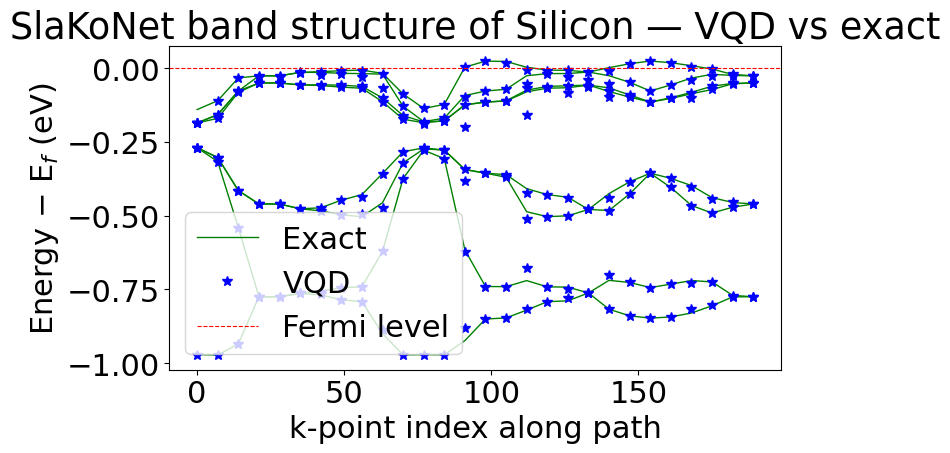

In [ ]:
# 4) Plot the band structure: markers = VQD (quantum), lines = exact.
plt.figure(figsize=(8, 5))
for b in range(eig_np.shape[1]):
    plt.plot(kept, eig_np[:, b], "-", c="green", lw=1, label="Exact" if b == 0 else "")
for b in range(eig_vqd.shape[1]):
    plt.plot(kept, eig_vqd[:, b], "*", c="blue", ms=7, label="VQD" if b == 0 else "")
plt.axhline(0, color="red", ls="--", lw=0.8, label="Fermi level")
plt.xlabel("k-point index along path"); plt.ylabel("Energy − E$_f$ (eV)")
plt.title("SlaKoNet band structure of Silicon — VQD vs exact")
plt.legend(); plt.tight_layout(); plt.savefig("slakonet_band_structure.png", dpi=150); plt.show()

> **Tip.** ADAPT-VQE (Part 4) also works on SlaKoNet's $H(k)$ — just feed
> `SparsePauliOp.from_operator(to_qubit_hamiltonian(hk_sk, nq_sk))` into `run_adapt_vqe`.

## 7. (Optional) Run on real IBM Quantum hardware

Everything above ran on a simulator. To run the *same* VQE on a real superconducting QPU:
1. Sign in at **https://quantum.cloud.ibm.com** and create an **API token** from the dashboard.
2. Paste it below and run `save_account` (once per environment).
3. Use **SPSA** with few iterations so you submit ~tens of jobs, not hundreds.

Expect queue time, finite shots, and device noise — energies will sit a bit above the
simulator. Record the **backend name + calibration date** for reproducibility.

In [ ]:
!pip install -q qiskit-ibm-runtime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.3/111.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.0/218.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.9 MB/s eta 0:00:00


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

token = ""    # <-- paste your IBM Quantum token here
if token:
    QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform", token=token,
        overwrite=True, set_as_default=True,
    )
    print("IBM account saved.")
else:
    print("No token set — skip Part 7 and stay on the simulator.")

No token set — skip Part 7 and stay on the simulator.


In [ ]:
# Runs only if you set a token above. Uncomment to submit to hardware.
# from qiskit_algorithms.optimizers import SPSA
# circ_hw = QuantumCircuitLibrary(n_qubits=n_qubits, reps=1).circuit6()
# en_hw, _, _ = HS.run_vqe(
#     var_form=circ_hw,
#     backend="ibm_brisbane",         # pick an available backend from your dashboard
#     optimizer=SPSA(maxiter=30),     # ~60 jobs total instead of hundreds
# )
# print("VQE on hardware - Ef :", round(en_hw - Ef, 5), "eV")

## 8. Where to go next — AtomGPT & JARVIS

This tutorial is one corner of a larger materials-AI ecosystem:

- **JARVIS** (https://jarvis.nist.gov) — 80,000+ materials, DFT data, and tools (the Wannier Hamiltonians in Parts 2–5 come from here).
- **AtomGPT.org** (https://atomgpt.org) — foundation models + 50+ domain apps:
  - **SlaKoNet** (https://atomgpt.org/slakonet) — the learned tight-binding $H(k)$ used in Part 6.
  - **ALIGNN / ALIGNN-FF** — graph-network property prediction & force fields.
  - **Quantum Explorer** (https://atomgpt.org/quantum) — runs VQE / ADAPT-VQE / VQD in the browser (the ADAPT-VQE code in Part 4 mirrors this service).

In [ ]:
# A few JARVIS materials with electronic Wannier Hamiltonians to try in Parts 2-5.
# Swap the JID into get_wann_electron(...) and re-run.
candidates = {
    "Al (FCC metal)":        "JVASP-816",
    "Si (semiconductor)":    "JVASP-1002",
}
for name, jid in candidates.items():
    print(f"{name:24s} -> {jid}")

Al (FCC metal)           -> JVASP-816
Si (semiconductor)       -> JVASP-1002


## 9. Exercises

1. **Different k-point.** In Part 2, set `kpt = [0.0, 0.0, 0.0]` (the $\Gamma$ point). How do the eigenvalues (relative to $E_f$) change, and why?
2. **Optimizer study.** `HS.run_vqe(..., optimizer=...)` accepts `COBYLA`, `SPSA`, `SLSQP` from `qiskit_algorithms.optimizers`. Which converges in the fewest evaluations on the simulator?
3. **Ansatz depth.** Vary `reps` in `circuit6()` (Part 3). What is the *shallowest* circuit that still reaches ~meV accuracy?
4. **ADAPT-VQE tuning.** In Part 4, tighten `gradient_threshold` (e.g. `1e-5`) and shrink the pool to single-qubit `Y` + two-qubit `YZ` only. How do iterations, depth, and final error change?
5. **VQE vs ADAPT-VQE.** For Si (`JVASP-1002`), compare the final circuit **depth** of fixed VQE vs ADAPT-VQE at matched accuracy.
6. **Another material with SlaKoNet.** Change `get_atoms("JVASP-1002")` in Part 6 to a material **without** Wannier data and rebuild the bands — the power of a *learned* $H(k)$.

---
*Built for the QC4MC Summer School @ ASU. Questions: drkamal@jhu.edu · github.com/atomgptlab · atomgpt.org/quantum*